In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from curve_fitting import *
from plotting_utils import *
from read_hatch import *

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = True

# Overview of hindcasting data

In [13]:
# load data
test = False
deduplicated = True

all_columns = ['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Start_index', 'Length_train', 'Length_test', 'Hindcast_MAPE', 
       'd', 'd_std', 'error_type', 'error_msg']
col_subset = ['functional_form', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'technology', 'Start_index', 'Length_train', 'Length_test', 'Hindcast_MAPE', 
       'd', 'd_std']

#old:
# """
if test:
       res = pd.read_parquet('data/conthind_results_all_2024-11-17_test_batch.parquet', columns=col_subset)
elif deduplicated:
       # load deduplicated set
       res = pd.read_parquet('results/conthind_results_all_2025-10-26.parquet')
else:
       # load parquet file provided by Zach
       res = pd.read_parquet('results/conthind_results_all_2025-07-14.parquet', columns=col_subset)


In [14]:
print(len(res))
res.columns

5015610


Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flag', 'technology', 'Start_index',
       'Length_train', 'Length_test', 'Hindcast_MAPE', 'outside_CI', 'CI_size',
       'd', 'd_std', 'error_type', 'error_msg'],
      dtype='object')

In [15]:
subset = res.loc[res['technology'] == 'NatGas Power_Cumulative Total Capacity_World',]

In [16]:
#res.head(1000).to_parquet('data/conthind_results_all_2024-11-17_test_batch.parquet')

<Axes: xlabel='Length_train'>

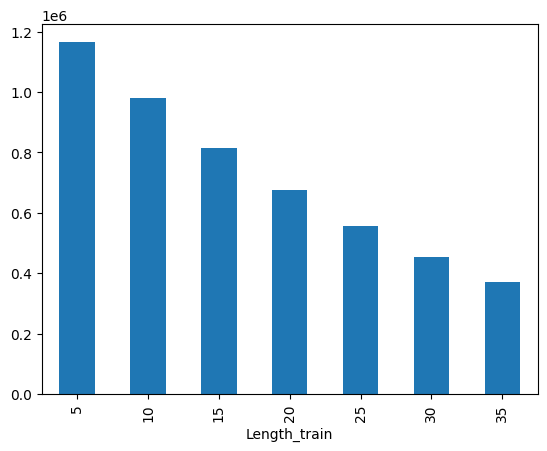

In [17]:
res['Length_train'].value_counts().sort_index().plot.bar()

<Axes: xlabel='Length_test'>

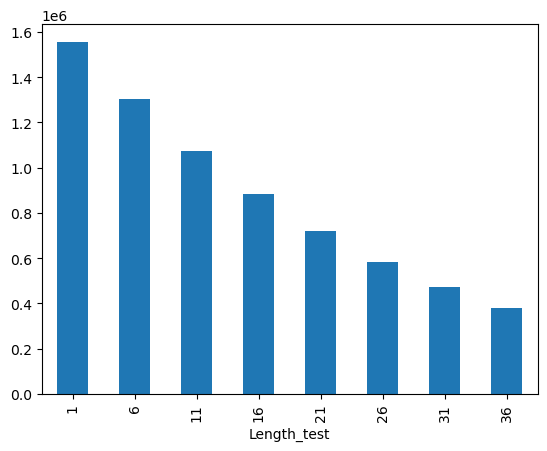

In [8]:
res['Length_test'].value_counts().sort_index().plot.bar()

## Correlations and dependencies between goodness of fit and prediction accuracy

In [18]:
res[['Length_test', 'Length_train']].value_counts().unstack()

Length_train,5,10,15,20,25,30,35
Length_test,,,,,,,
1,236043,204156,174285,147429,123408,101754,82593
5,210024,179586,152136,127719,105849,86139,68310
10,179586,152136,127719,105849,86139,68310,55170
15,152136,127719,105849,86139,68310,55170,46143
20,127719,105849,86139,68310,55170,46143,38034
25,105849,86139,68310,55170,46143,38034,31608
30,86139,68310,55170,46143,38034,31608,26748
35,68310,55170,46143,38034,31608,26748,23022


146038


<Axes: xlabel='adj_r_squared', ylabel='MAPE'>

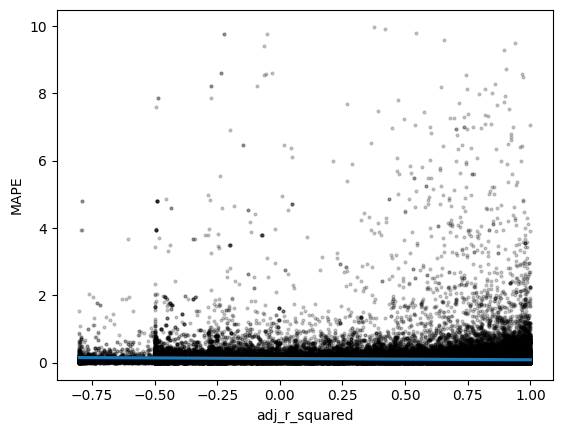

In [20]:
resf = res[(res['Length_test'] == 5) & (res['Length_train'] == 10)]

resf = resf[(resf['MAPE'] < 10) & (resf['r_squared'] > 0)]

print(len(resf))

sns.regplot(data=resf, x='adj_r_squared', y='MAPE', scatter_kws={'s': 4, 'color': 'black', 'alpha': 0.2})

In [11]:
# Pearson correlation
resf[['r_squared', 'MAPE']].corr()

,r_squared,MAPE
r_squared,1.000000,-0.047595
MAPE,-0.047595,1.000000


In [12]:
# rank correlation
resf[['r_squared', 'MAPE']].corr('spearman')

,r_squared,MAPE
r_squared,1.000000,-0.612739
MAPE,-0.612739,1.000000


In [13]:
import statsmodels.api as sm

x = resf['r_squared']
y = resf['MAPE']

x = sm.add_constant(x)
model = sm.OLS(y,x)
results = model.fit()
# print(results.params)
print(results.params)
print(results.f_pvalue)

const        0.111430
r_squared   -0.049267
dtype: float64
7.709690050124909e-114


## remove duplicates

In [21]:
# check for duplicates
n_duplicates = res.duplicated().sum()
print("pct duplicates", 100 * n_duplicates / len(res))

pct duplicates 0.0


In [15]:
if not deduplicated:
    print(len(res))
    # duplicates
    n_duplicates = res.duplicated().sum()
    print("pct duplicates", 100 * n_duplicates / len(res))

    # duplicates across functional forms
    for ff in res['functional_form'].unique():
        print(res[res['functional_form'] == ff].duplicated().sum())
   
    ddres = res.drop_duplicates()
    print(len(ddres))
    print((ddres['Length_test'] == 0).sum())
    ddres = ddres[ddres['Length_test'] > 0]
    print(len(ddres))

    # save deduplicated set
    ddres.to_parquet('results/conthind_results_all_2025-03-23_deduplicated.parquet')    

### Look at subset

Text(0, 0.5, 'log MAPE')

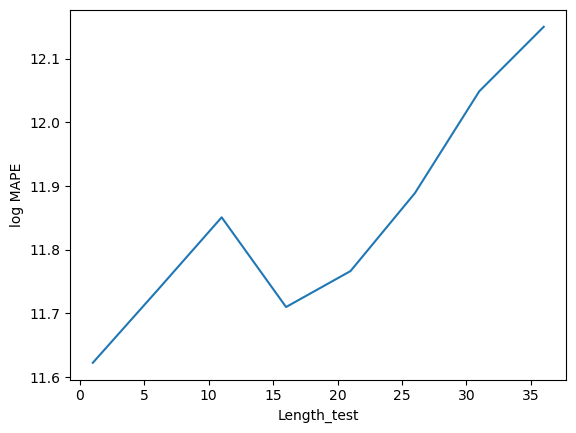

In [16]:
ltrain = 20
resf = res[res['Length_train'] == ltrain]
resf.groupby('Length_test')['Hindcast_MAPE'].mean().apply(np.log10).plot()
plt.ylabel('log MAPE')

<Axes: xlabel='Length_test'>

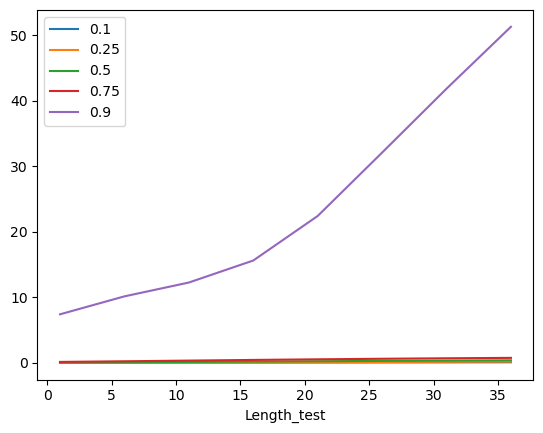

In [17]:
qs = resf.groupby('Length_test')['Hindcast_MAPE'].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()
qs.plot()


<Axes: xlabel='Length_test'>

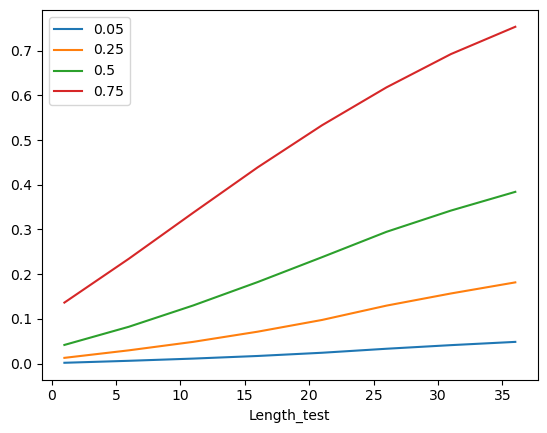

In [18]:
qs = resf.groupby('Length_test')['Hindcast_MAPE'].quantile([0.05, 0.25, 0.5, 0.75]).unstack()
qs.plot()

In [19]:
# percentage of MAPE values > x
100 * resf[resf['Hindcast_MAPE'] > 10]['functional_form'].value_counts() / resf['functional_form'].value_counts()

functional_form
bass                     0.130389
bertalanffy              0.147775
exponential              0.979369
gompertz                 0.312935
linear                   0.117833
logistic                 0.339978
logistic-linear-cont    90.384021
richards                 0.337081
softplus                 0.335149
Name: count, dtype: float64

# Plot hindcasting illustration 

In [22]:
df = read_hatch('data/HATCH_v1.5_clean.csv')

all_years = pd.to_numeric(df.columns, errors='coerce').dropna().astype(int)

#Group metrics to get cumulative sum of annual data
# correct internally inconsistent labels
df['Metric'] = df['Metric'].replace({'Annual production': 'Annual Production',
                                     'Cumulative total capacity': 'Cumulative Total Capacity'})
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
df.insert(loc = 6, column='metric_grouped', value = df['Metric'].map(group_metrics))



Removed timeseries with less than 10 data points: 1681
Removed timeseries with constant values: 68
Removed data within the following number of timeseries that are during the formative phase:


C:\Users\zacht\AppData\Local\Temp\ipykernel_1908\2993613836.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(loc = 6, column='metric_grouped', value = df['Metric'].map(group_metrics))


In [23]:
from sklearn.metrics import mean_absolute_percentage_error
from predict import predict_mape

In [24]:
res.head()

,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,Start_index,Length_train,Length_test,Hindcast_MAPE,outside_CI,CI_size,d,d_std,error_type,error_msg
0,exponential,curve_fit,True,0.453552,-1.185794,3.558472,3.179435,0.049272,2.119751e+01,0.039585,...,0,5,1,0.083368,0.0,2.266473e+07,NaN,NaN,None,None
1,linear,curve_fit,True,0.432432,-0.135135,3.024000,2.761542,0.050491,-1.380400e+03,0.800000,...,0,5,1,0.072727,0.0,1.687031e+02,NaN,NaN,None,None
2,logistic,curve_fit,True,0.453548,-1.185810,3.558498,3.179458,0.049270,1.158448e+05,0.039592,...,0,5,1,0.083356,0.0,1.875602e+09,NaN,NaN,None,None
3,gompertz,curve_fit,True,0.451960,-1.192159,3.568835,3.188694,0.049369,1.794745e+07,0.002890,...,0,5,1,0.082524,-1.0,1.546365e+03,NaN,NaN,None,None
4,softplus,curve_fit,True,0.453548,-1.185809,3.558498,3.179457,0.049272,2.357358e+03,0.039591,...,0,5,1,0.083363,2.0,NaN,NaN,NaN,None,None


0.08336810054626605
exponential
0.8137961077186106
0.8137961077186106


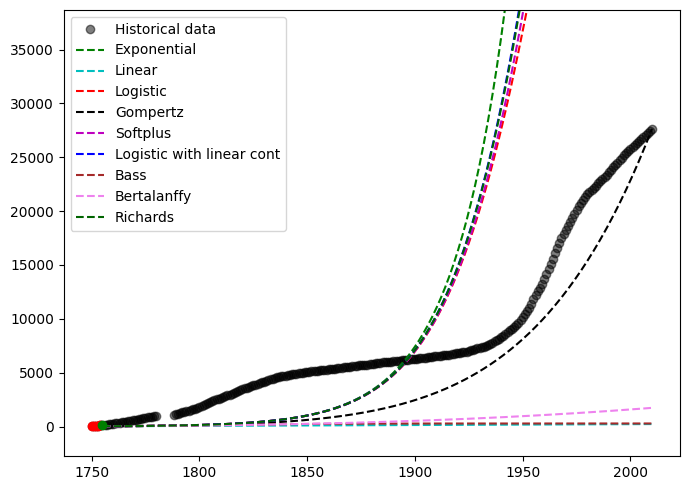

In [25]:
# plot for one set
i = 0
tech_name = res.iloc[i]['technology']
ltrain = res.iloc[i]['Length_train']
ltest = res.loc[i]['Length_test']
start_index = res.loc[i]['Start_index']

sl = df.iloc[df.index == tech_name, 10:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')
if df.loc[tech_name]['metric_grouped'] == 'annual':
    values = values.cumsum()
fig = plot_curve_fits(years, values, res.iloc[0:9].to_dict('records')) #, verbosity=1)
fig.gca().plot(years[:ltrain], values[:ltrain], 'o', color='r')

test_ydata = values[ltrain:(ltrain+ltest)]
test_xdata = years[ltrain:(ltrain+ltest)]
fig.gca().plot(test_xdata, test_ydata, 'o', color='g')

print(res.iloc[i]['Hindcast_MAPE'])
print(res.iloc[i]['functional_form'])

# test whether computation of MAPE is correct:
popt = [res.iloc[i]['a'], res.iloc[i]['b'], res.iloc[i]['c']]

mape = mean_absolute_percentage_error(test_ydata, exp_func(test_xdata, *popt))
print(mape)

mape_recalc = predict_mape([res.iloc[i].to_dict()], test_xdata, test_ydata)
print(mape_recalc[0]['Hindcast_MAPE'])


### Plot multiple examples with extreme MAPE

Check why MAPE is so huge for some timeseries!

In [8]:
extremes = resf[(resf['Hindcast_MAPE'] > 200) & (resf['functional_form'] == 'logistic') & (resf['Length_test'] == 30)]
print(len(extremes))
extremes = extremes.drop_duplicates()
print(len(extremes))

NameError: name 'resf' is not defined

In [25]:
asdf = res.loc[(res['Start_index'] == start_index) & (res['technology'] == 'Crude Petroleum_Annual Production_US') & (res['Length_test'] == 26) & (res['Length_train'] == 25)]

Text(0, 0.5, 'US Crude')

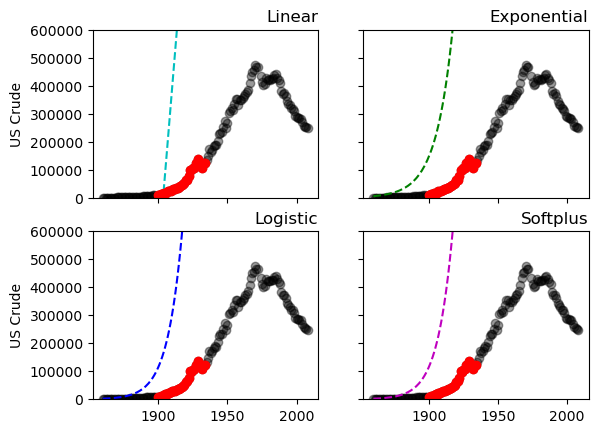

In [26]:
# plot for one set
tech_name = 'Crude Petroleum_Annual Production_US'
# tech_name = 'Biogas_Installed electricity capacity_PK'
ltrain = 35
ltest = 36
start_index = 40

fitdata = res.loc[(res['Start_index'] == start_index) & \
                  (res['technology'] == tech_name) & \
                  (res['Length_test'] == ltest) & (res['Length_train'] == ltrain)].to_dict('records')

sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')

fig, axis = plt.subplots(2,2, sharey = True, sharex=True)

plt.ylim(0,600000)

axis[0,0].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[0,1].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[1,0].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[1,1].plot(years, values, 'ko', label='Historical data', alpha = 0.4)

linpopt = [fitdata[1][k] for k in ['a','b']]
axis[0,0].plot(years, linear_func(years, *linpopt), 'c--')

exppopt = [fitdata[0][k] for k in ['a','b', 'c']]
axis[0,1].plot(years, exp_func(years, *exppopt), 'g--')

logpopt = [fitdata[2][k] for k in ['a','b','c']]
axis[1,0].plot(years, logistic_func(years, *logpopt), 'b--')

# logpopt = [fitdata[2][k] for k in ['a','b','c']]
# axis[0,1].plot(years, logistic_func(years, *logpopt), 'b')
# gompopt = [fitdata[3][k] for k in ['a','b','c']]
# axis[0,1].plot(years, gompertz_func3(years, *gompopt), 'k--')
# baspopt = [fitdata[6][k] for k in ['a','b','c', 'd']]
# axis[0,1].plot(years, bass_func(years, *baspopt), '--', c='brown')
# berpopt = [fitdata[7][k] for k in ['a','b','c']]
# axis[0,1].plot(years, bertalanffy_func3(years, *berpopt), '--', c='violet')
# ricpopt = [fitdata[8][k] for k in ['a','b','c', 'd']]
# axis[0,1].plot(years, logistic_func(years, *logpopt), 'r--')

# exppopt = [fitdata[0][k] for k in ['a','b', 'c']]
# axis[1,0].plot(years, exp_func(years, *exppopt), 'g--')
# linpopt = [fitdata[1][k] for k in ['a','b']]
# axis[1,0].plot(years, linear_func(years, *linpopt), 'c--')

sofpopt = [fitdata[4][k] for k in ['a','b','c']]
axis[1,1].plot(years, softplus_func(years, *sofpopt), 'm--')
# lwcpopt = [fitdata[5][k] for k in ['a','b','c']]
# axis[1,1].plot(years, logistic_linear_cont(years, *lwcpopt), 'r--')

axis[0,0].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[0,1].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[1,0].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[1,1].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')

axis[0,0].set_title('Linear', loc = 'right')
axis[0,1].set_title('Exponential', loc = 'right')
axis[1,0].set_title('Logistic', loc = 'right')
axis[1,1].set_title('Softplus', loc = 'right')

axis[0,0].set_ylabel('US Crude')
axis[1,0].set_ylabel('US Crude')

Text(0.5, 1.0, '')

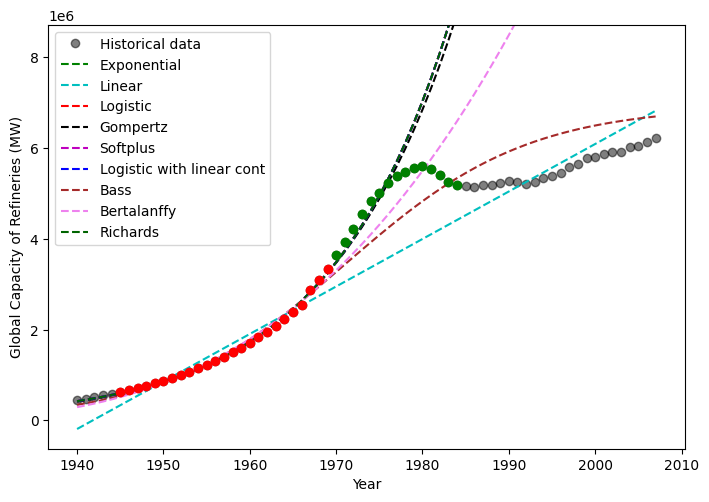

In [30]:
# plot for one set
#tech_name = 'Crude Petroleum_Annual Production_US'
#tech_name = 'Nuclear Energy_Annual Production_World'
tech_name = 'FCC-Refineries_Net Total Capacity_World'
ltrain = 25
ltest = 15
start_index = 5

fitdata = res.loc[(res['Start_index'] == start_index) & \
                  (res['technology'] == tech_name) & \
                  (res['Length_test'] == ltest) & (res['Length_train'] == ltrain)].to_dict('records')

sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
metadata = df.iloc[df.index == tech_name, :9]
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')
if df.loc[tech_name]['metric_grouped'] == 'annual':
    values = values.cumsum()

fig = plot_curve_fits(years, values, fitdata, tech_name=tech_name) #, verbosity=1)
fig.gca().plot(years[start_index:(ltrain+start_index)], values[start_index:(ltrain+start_index)], 'o', color='r')
# plot test data
test_ydata = values[ltrain+start_index:(ltrain+start_index+ltest)]
test_xdata = years[ltrain+start_index:(ltrain+start_index+ltest)]
fig.gca().plot(test_xdata, test_ydata, 'o', color='g')
fig.gca().set_ylabel('Global Capacity of Refineries ('+metadata['Unit'].values[0]+')')
fig.gca().set_xlabel('Year')
fig.gca().set_title('')

# if save_fig:
#     fig.savefig(f'figures/hindcasting/{tech_name}_{ltrain}_{ltest}_{start_index}.png', **savefig_settings)
#     fig.savefig(f'figures/hindcasting/{tech_name}_{ltrain}_{ltest}_{start_index}.svg', **savefig_settings)

In [29]:
metadata

,Spatial Scale,Region,Country Name,Technology Name,Metric,Unit,metric_grouped,Data Source,Variable
ID,,,,,,,,,
FCC-Refineries_Net Total Capacity_World,Global,World,World,Fluid Catalytic Cracking Refineries,Net Total Capacity,MW,cumulative,Wilson & Grubler,Net Total Capacity|Fluid Catalytic Cracking Re...


In [ ]:
df['Spatial Scale'].value_counts()

Spatial Scale
National    3693
Global        18
Name: count, dtype: int64

In [ ]:
# to find suitable time series
#df[df['Spatial Scale'] == 'Global']

In [ ]:
df[(df['metric_grouped'] == 'share') & df['Spatial Scale'] == 'Global']

,Spatial Scale,Region,Country Name,Technology Name,Metric,Unit,metric_grouped,Data Source,Variable,1700,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ID,,,,,,,,,,,,,,,,,,,,,


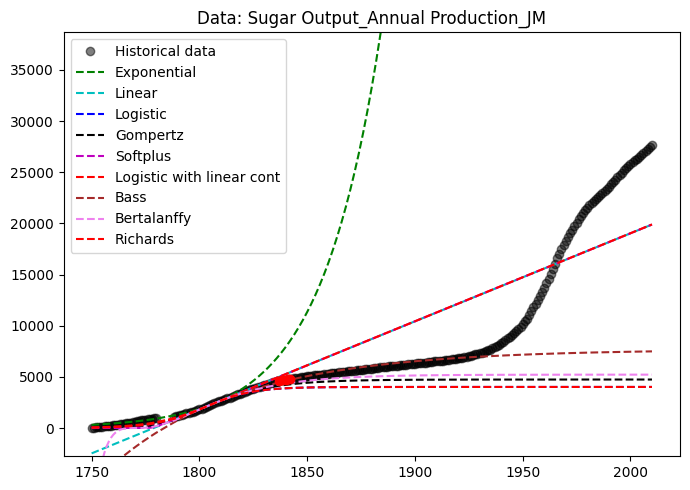

In [ ]:
# plot for one set
tech_name = res.iloc[0]['technology']
ltrain = 6
start_index = 80

fitdata = res.iloc[4608:4617].to_dict('records')

sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')
if df.loc[tech_name]['metric_grouped'] == 'annual':
    values = values.cumsum()
fig = plot_curve_fits(years, values, fitdata, tech_name=tech_name) #, verbosity=1)
fig.gca().plot(years[start_index:(ltrain+start_index)], values[start_index:(ltrain+start_index)], 'o', color='r')

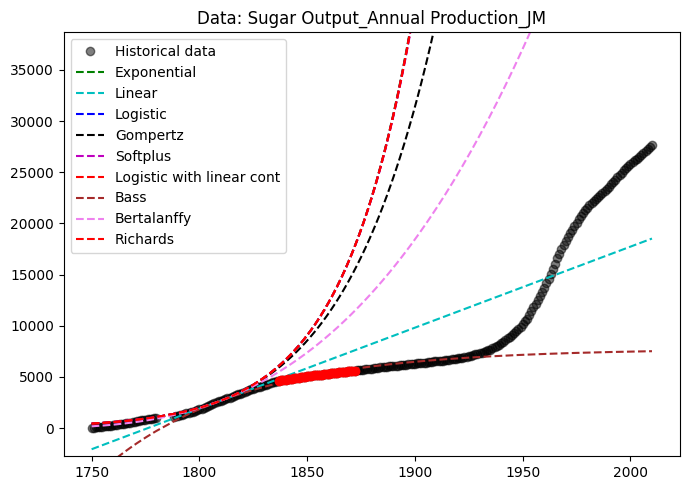

In [ ]:
# plot for one set
tech_name = res.iloc[0]['technology']
ltrain = 36
start_index = 80

fitdata = res.iloc[5040:5049].to_dict('records')

sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')
if df.loc[tech_name]['metric_grouped'] == 'annual':
    values = values.cumsum()
fig = plot_curve_fits(years, values, fitdata, tech_name=tech_name) #, verbosity=1)
fig.gca().plot(years[start_index:(ltrain+start_index)], values[start_index:(ltrain+start_index)], 'o', color='r')

### Plot multiple examples with extreme MAPE

In [ ]:
extremes = resf[(resf['Hindcast_MAPE'] > 20) & (resf['functional_form'] == 'logistic') & (resf['Length_test'] == 30)]
print(len(extremes))
extremes = extremes.drop_duplicates()
print(len(extremes))

0
0


In [ ]:
for i in extremes.index:
    tech_name = res.loc[i]['technology']
    ltrain = res.loc[i]['Length_train']
    ltest = res.loc[i]['Length_test']

    sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
    years = sl.index.to_numpy(dtype='float')
    values = sl.to_numpy(dtype='float')
    if df.loc[tech_name]['metric_grouped'] == 'annual':
        values = values.cumsum()
    fig = plot_curve_fits(years, values, res.loc[i:i].to_dict('records'), tech_name=res.loc[i]['technology']) #, verbosity=1)
    fig.gca().plot(years[:ltrain], values[:ltrain], 'o', color='r')
    test_ydata = values[ltrain:(ltrain+ltest)]
    test_xdata = years[ltrain:(ltrain+ltest)]
    fig.gca().plot(test_xdata, test_ydata, 'o', color='g')

    # recompute MAPE
    print("MAPE from dataset", res.loc[i]['Hindcast_MAPE'])
    
    popt = [res.loc[i]['a'], res.loc[i]['b'], res.loc[i]['c']]

    mape = mean_absolute_percentage_error(test_ydata, logistic_func(test_xdata, *popt))
    print("recomputed MAPE", mape)

    mape_recalc = predict_mape([res.loc[i].to_dict()], test_xdata, test_ydata)
    print("recalc using original func", mape_recalc[0]['Hindcast_MAPE'])


In [ ]:
# Check MAPE calculations for random sample

random_sample_index = np.random.choice(res.index, size=1000, replace=True)

mape_df = pd.DataFrame(columns=['MAPE_orig', 'MAPE_recalc'])

for i in random_sample_index:
    tech_name = res.loc[i]['technology']
    ltrain = res.loc[i]['Length_train']
    ltest = res.loc[i]['Length_test']

    sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
    years = sl.index.to_numpy(dtype='float')
    values = sl.to_numpy(dtype='float')
    test_ydata = values[ltrain:(ltrain+ltest)]
    test_xdata = years[ltrain:(ltrain+ltest)]

    # recompute MAPE
    mape_df.loc[i, 'MAPE_orig'] = res.loc[i]['Hindcast_MAPE']

    mape_recalc = predict_mape([res.loc[i].to_dict()], test_xdata, test_ydata)
    mape_df.loc[i, 'MAPE_recalc'] = mape_recalc[0]['Hindcast_MAPE']


/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/numpy/ma/core.py:949: RuntimeWarning: overflow encountered in exp
  result = self.f(d, *args, **kwargs)
/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/numpy/ma/core.py:949: RuntimeWarning: overflow encountered in exp
  result = self.f(d, *args, **kwargs)


In [ ]:
((mape_df['MAPE_orig'] - mape_df['MAPE_recalc']) < 1e-8).sum()

NameError: name 'mape_df' is not defined

## Notes:

Reasons for extreme MAPE values:
- Jumps or trend breaks in the data at the cutoff of the training dataset -> smooting or data series removal before evaluation

60% of the data points are duplicates in the set, evenly distributed across functional forms -> remove them!

Using only early data points systematically biases the evaluation towards linear or exponential models